# PID Fault Example - New API (Orchestrator)

This notebook translates the old `PID_reg_old.ipynb` logic into the current API.

In [35]:
import os
import sys

sys.path.append(os.path.abspath('../..'))


In [36]:
import pandas as pd
import matplotlib.pyplot as plt

from complex_granger_analysis.api import (
    MultiTaskGrangerAPI,
    SimpleGrangerAPI,
 )
from complex_granger_analysis.backends.backend_factory import BackendFactory
from complex_granger_analysis.backends.callbacks import EarlyStopping
from complex_granger_analysis.core.lag_config import LagConfiguration
from complex_granger_analysis.initializers import OLSInitializer, RandomNormalInitializer
from complex_granger_analysis.preprocessing.lag import lag_selectors
from complex_granger_analysis.preprocessing.stationarity import StationarityTransformer

In [37]:
dane = pd.read_csv('PID_fault1.csv', sep=';', index_col='Unnamed: 0')
dane2 = pd.read_csv('PID_fault2.csv', sep=';', index_col='Unnamed: 0')

# Legacy compatibility step from the old notebook
dane['f2'] = 0
dane2['f1'] = 0

data_df = pd.concat([dane, dane2], ignore_index=True)
data_df.head()

,x1,x2,u1,e1,u,f1,f2
0,-0.000259,0.015492,0.046253,0.997807,0.989189,0.0,0.0
1,-0.005809,0.031458,0.091250,0.989298,1.016789,0.0,0.0
2,0.013939,-0.013906,0.105426,1.020242,1.009915,0.0,0.0
3,0.074378,-0.024593,0.120791,0.995992,1.033317,0.0,0.0
4,0.129618,-0.009213,0.133380,0.958442,1.041769,0.0,0.0


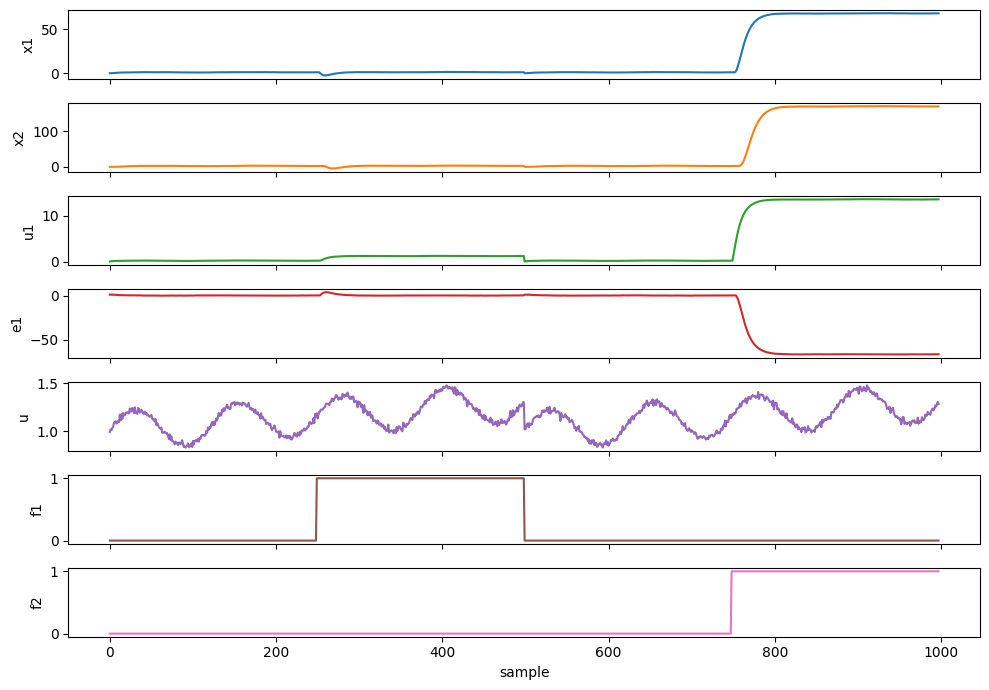

In [38]:
fig, ax = plt.subplots(len(data_df.columns), figsize=(10, 7), sharex=True)
plot_cols = list(data_df.columns)
data_df[plot_cols].plot(subplots=True, legend=False, ax=ax)
for i, axis in enumerate(ax):
    axis.set_ylabel(plot_cols[i])
ax[-1].set_xlabel('sample')
plt.tight_layout()
plt.show()

## Classical pair-wise Granger

In [39]:
simple_api = SimpleGrangerAPI()
simple_out = simple_api.fit(
    data=data_df.copy(),
    test='ssr_ftest',
    lag_max=8,
    threshold=0.01,
 )

print('Classical causality matrix (signed binary):')
display(simple_out.causality_matrix.data)

Classical causality matrix (signed binary):


/home/janek/miniconda3/envs/pt/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/janek/miniconda3/envs/pt/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/janek/miniconda3/envs/pt/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/janek/miniconda3/envs/pt/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/janek/miniconda3/envs/pt/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/janek/miniconda3/envs/pt/lib/python3.13/site

,x1,x2,u1,e1,u,f1,f2
x1,0.0,-1.0,1.0,1.0,-1.0,-1.0,1.0
x2,1.0,0.0,1.0,-1.0,-1.0,-1.0,0.0
u1,-1.0,-1.0,0.0,1.0,-1.0,-1.0,1.0
e1,-1.0,1.0,-1.0,0.0,-1.0,1.0,-1.0
u,0.0,0.0,1.0,0.0,0.0,0.0,0.0
f1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
f2,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [40]:
print('Classical p-value matrix:')
display(simple_out.p_value)

print('Classical sign matrix:')
display(simple_out.sign)

Classical p-value matrix:


,x1,x2,u1,e1,u,f1,f2
x1,1.000000e+00,1.454457e-40,5.078983e-92,6.741479e-16,2.182620e-06,3.108991e-47,1.619811e-96
x2,2.794941e-153,1.000000e+00,4.227774e-71,2.284145e-155,3.090088e-12,2.502743e-40,9.999805e-01
u1,2.412691e-08,6.050877e-11,1.000000e+00,3.788245e-04,3.268069e-04,5.129158e-19,3.522678e-149
e1,2.504265e-272,6.235669e-14,1.011065e-95,1.000000e+00,1.819775e-76,1.022806e-27,9.753645e-84
u,1.181653e-01,1.920518e-02,3.093448e-03,3.363208e-01,1.000000e+00,1.107102e-01,8.726916e-01
f1,9.999178e-01,9.999254e-01,1.000000e+00,8.982857e-01,2.405772e-01,1.000000e+00,1.000000e+00
f2,9.999754e-01,9.999667e-01,1.000000e+00,7.938269e-01,9.624035e-02,1.000000e+00,1.000000e+00


Classical sign matrix:


,x1,x2,u1,e1,u,f1,f2
x1,1.0,-1.0,1.0,1.0,-1.0,-1.0,1.0
x2,1.0,1.0,1.0,-1.0,-1.0,-1.0,-1.0
u1,-1.0,-1.0,1.0,1.0,-1.0,-1.0,1.0
e1,-1.0,1.0,-1.0,1.0,-1.0,1.0,-1.0
u,1.0,1.0,1.0,-1.0,1.0,1.0,1.0
f1,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0
f2,1.0,1.0,1.0,-1.0,-1.0,0.0,-1.0


## Multivariable Granger - backend equivalents of old classes

In [41]:
available = BackendFactory.list_available_backends()
print('Available backends:', available)
if not available:
    raise RuntimeError('No backend available. Install tensorflow, torch, or scikit-learn.')

def run_multitask(
    backend_name,
    *,
    data,
    causes=None,
    effects=None,
    tested_causes=None,
    relations=None,
    lag_config=None,
    lag_selector=None,
    regularizer_spec=None,
    callbacks=None,
    model_config=None,
    initializer=None,
    hiperoptimalization_state=None,
    hiperoptimalization_conf=None,
 ):
    api = MultiTaskGrangerAPI(backend=backend_name, reuse_data=True)
    return api.fit(
        data=data,
        causes=causes,
        effects=effects,
        tested_causes=tested_causes,
        relations=relations,
        lag_config=lag_config,
        lag_selector=lag_selector,
        stationarity_transformer=StationarityTransformer(max_differencing_order=1),
        x_scaler='standard',
        y_scaler='standard',
        regularizer_spec=regularizer_spec,
        callbacks=callbacks,
        model_config=model_config,
        initializer=initializer,
        hiperoptimalization_state=hiperoptimalization_state,
        hiperoptimalization_conf=hiperoptimalization_conf,
    )

Available backends: ['pytorch', 'sklearn']


## Scikit-learn (Newton gradient method)

It is better to give list of tables, because class can better handle table conections without creating transition zone that would create false causalities.

In [42]:
if 'sklearn' in available:
    out_sklearn = run_multitask(
        'sklearn',
        data=[dane, dane2],
        lag_config=LagConfiguration(max_lag=8, use_lag_zero=False),
        model_config={'max_iter': 3000, 'learning_rate': 1.0, 'verbose': 0},
    )
    print('SparseConstrainedMVGC equivalent (backend=scikit):')
    display(out_sklearn.results.result(threshold=0.01, with_sign=True))
else:
    print('Skipping scikit backend test - backend not available.')

SparseConstrainedMVGC equivalent (backend=scikit):


,x1,x2,u1,e1,u,f1,f2
x1,0.0,0.0,1.0,0.0,0.0,-1.0,0.0
x2,1.0,1.0,0.0,0.0,0.0,0.0,0.0
u1,-1.0,0.0,1.0,-1.0,1.0,0.0,1.0
e1,-1.0,0.0,0.0,-1.0,1.0,0.0,0.0
u,-1.0,-1.0,0.0,-1.0,1.0,0.0,0.0
f1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
f2,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Tensorflow (gradient descend with optimizer)

Optimizer can be changed as parameter of class constructor. Initial optimizer is Adam

In [43]:
if 'tensorflow' in available:
    out_tf = run_multitask(
        'tensorflow',
        data=[dane, dane2],
        lag_config=LagConfiguration(max_lag=8, use_lag_zero=False),
        model_config={'epochs': 40, 'batch_size': 32, 'verbose': 0, 'optimizer': 'adam'},
    )
    print('TFNeuralSparseConstrainedMVGC equivalent (backend=tensorflow):')
    display(out_tf.results.result(threshold=0.01, with_sign=True))
    print('p-value matrix:')
    display(out_tf.results.p_value)
else:
    print('Skipping tensorflow backend test - backend not available.')

Skipping tensorflow backend test - backend not available.


## Pytorch (gradient descend with optimizer)

Optimizer can be changed as parameter of class constructor. Initial optimizer is Adam

In [44]:
if 'pytorch' in available:
    out_pt = run_multitask(
        'pytorch',
        data=[dane, dane2],
        lag_config=LagConfiguration(max_lag=8, use_lag_zero=False),
        model_config={'epochs': 40, 'batch_size': 32, 'verbose': 0, 'optimizer': 'adam'},
    )
    print('PTNeuralSparseConstrainedMVGC equivalent (backend=pytorch):')
    display(out_pt.results.result(threshold=0.01, with_sign=True))
    print('p-value matrix:')
    display(out_pt.results.p_value)
else:
    print('Skipping pytorch backend test - backend not available.')

PTNeuralSparseConstrainedMVGC equivalent (backend=pytorch):


,x1,x2,u1,e1,u,f1,f2
x1,0.0,0.0,1.0,0.0,0.0,-1.0,0.0
x2,0.0,1.0,0.0,0.0,0.0,0.0,0.0
u1,0.0,0.0,0.0,0.0,0.0,0.0,1.0
e1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u,0.0,0.0,0.0,0.0,1.0,0.0,0.0
f1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
f2,0.0,0.0,0.0,0.0,0.0,0.0,0.0


p-value matrix:


,x1,x2,u1,e1,u,f1,f2
x1,1.0,1.000000e+00,1.110223e-16,1.0,1.000000e+00,1.110223e-16,1.634818e-01
x2,1.0,1.110223e-16,1.000000e+00,1.0,1.000000e+00,1.000000e+00,1.000000e+00
u1,1.0,1.000000e+00,1.000000e+00,1.0,1.000000e+00,1.000000e+00,1.110223e-16
e1,1.0,1.000000e+00,1.000000e+00,1.0,1.000000e+00,1.000000e+00,1.000000e+00
u,1.0,1.000000e+00,1.000000e+00,1.0,1.110223e-16,1.000000e+00,1.000000e+00
f1,1.0,1.000000e+00,1.000000e+00,1.0,9.100252e-01,1.000000e+00,1.000000e+00
f2,1.0,1.000000e+00,1.000000e+00,1.0,8.563171e-01,1.000000e+00,1.000000e+00


# Feature parity: limiting analyzed variables + lag controls

In [45]:
preferred_backend = 'pytorch' if 'pytorch' in available else available[0]
print('Using backend for feature parity tests:', preferred_backend)


Using backend for feature parity tests: pytorch


## Limiting causes/effects (old: effects=[...], causes=[...])


In [46]:
out_subset = run_multitask(
    preferred_backend,
    data=[dane, dane2],
    causes=['f1', 'f2', 'x1', 'x2', 'u1', 'e1'],
    effects=['x1', 'x2', 'u1'],
    tested_causes=['f1', 'f2'],
    lag_config=LagConfiguration(max_lag=8, use_lag_zero=False),
    model_config={'epochs': 25, 'batch_size': 32, 'verbose': 0} if preferred_backend != 'sklearn' else {'max_iter': 2000, 'verbose': 0},
 )
print('Subset variables result:')
display(out_subset.results.result(threshold=0.01, with_sign=True))

Subset variables result:


,f1,f2
x1,0.0,0.0
x2,0.0,0.0
u1,0.0,1.0


# Lag control

## Manual control of max considered lag

In [47]:

out_lag_range = run_multitask(
    preferred_backend,
    data=[dane, dane2],
    lag_config=LagConfiguration(max_lag=10, use_lag_zero=False),
    model_config={'epochs': 25, 'batch_size': 32, 'verbose': 0} if preferred_backend != 'sklearn' else {'max_iter': 2000, 'verbose': 0},
 )
print('Lag range result (max_lag=10):')
display(out_lag_range.results.result(threshold=0.01, with_sign=True))

Lag range result (max_lag=10):


,x1,x2,u1,e1,u,f1,f2
x1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
x2,0.0,1.0,0.0,0.0,0.0,0.0,0.0
u1,0.0,0.0,0.0,0.0,0.0,0.0,1.0
e1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u,0.0,0.0,0.0,0.0,1.0,0.0,0.0
f1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
f2,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Fixed/common lag for all variables (old: base_lag=4)

In [48]:
all_vars = list(dane.columns)
fixed_lag_cfg = LagConfiguration(
    max_lag=10,
    use_lag_zero=False,
    custom_lags={name: (4, 4) for name in all_vars},
 )
out_fixed_lag = run_multitask(
    preferred_backend,
    data=[dane, dane2],
    lag_config=fixed_lag_cfg,
    model_config={'epochs': 25, 'batch_size': 32, 'verbose': 0} if preferred_backend != 'sklearn' else {'max_iter': 2000, 'verbose': 0},
 )
print('Fixed lag result (all variables lag=4):')
display(out_fixed_lag.results.result(threshold=0.01, with_sign=True))

Fixed lag result (all variables lag=4):


,x1,x2,u1,e1,u,f1,f2
x1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
x2,0.0,1.0,0.0,0.0,0.0,0.0,0.0
u1,0.0,0.0,1.0,0.0,0.0,0.0,0.0
e1,0.0,0.0,-1.0,0.0,0.0,0.0,0.0
u,0.0,0.0,0.0,0.0,1.0,0.0,0.0
f1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
f2,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Custom lag for chosen variable

In [49]:
custom_lag_cfg = LagConfiguration(
    max_lag=10,
    use_lag_zero=False,
    custom_lags={'x2': (3, 4)},
 )
out_custom_lag = run_multitask(
    preferred_backend,
    data=[dane, dane2],
    lag_config=custom_lag_cfg,
    model_config={'epochs': 25, 'batch_size': 32, 'verbose': 0} if preferred_backend != 'sklearn' else {'max_iter': 2000, 'verbose': 0},
 )
print('Custom lag result (x2 in [3,4]):')
display(out_custom_lag.results.result(threshold=0.01, with_sign=True))

Custom lag result (x2 in [3,4]):


,x1,x2,u1,e1,u,f1,f2
x1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
x2,0.0,1.0,0.0,0.0,0.0,0.0,0.0
u1,0.0,0.0,0.0,0.0,0.0,0.0,1.0
e1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u,0.0,0.0,0.0,0.0,1.0,0.0,0.0
f1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
f2,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Custom lag for chosen variable pair

In [50]:
pair_lag_cfg = LagConfiguration(
    max_lag=10,
    use_lag_zero=False,
    custom_pair_lags={('x1', 'x2'): (2, 5)},
)

out_pair_lag = run_multitask(
    preferred_backend,
    data=[dane, dane2],
    lag_config=pair_lag_cfg,
    model_config={
        'epochs': 25, 'batch_size': 32, 'verbose': 0
    } if preferred_backend != 'sklearn' else {
        'max_iter': 2000, 'verbose': 0
    },
)

print('Custom pair lag result ((effect, cause) = (x1, x2), lag range 2..5):')
display(out_pair_lag.results.result(threshold=0.01, with_sign=True))

Custom pair lag result ((effect, cause) = (x1, x2), lag range 2..5):


,x1,x2,u1,e1,u,f1,f2
x1,0.0,0.0,0.0,0.0,0.0,-1.0,0.0
x2,0.0,1.0,0.0,0.0,0.0,0.0,0.0
u1,0.0,0.0,0.0,0.0,0.0,0.0,1.0
e1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u,0.0,0.0,0.0,0.0,1.0,0.0,0.0
f1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
f2,0.0,0.0,0.0,0.0,0.0,0.0,0.0



## Add zero lag (old: use_zero_lag=True)


In [51]:
lag_zero_cfg = LagConfiguration(max_lag=8, use_lag_zero=True)
out_lag_zero = run_multitask(
    preferred_backend,
    data=[dane, dane2],
    lag_config=lag_zero_cfg,
    model_config={'epochs': 25, 'batch_size': 32, 'verbose': 0} if preferred_backend != 'sklearn' else {'max_iter': 2000, 'verbose': 0},
 )
print('Lag with zero result:')
display(out_lag_zero.results.result(threshold=0.01, with_sign=True))

Lag with zero result:


,x1,x2,u1,e1,u,f1,f2
x1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
x2,0.0,1.0,0.0,0.0,0.0,0.0,0.0
u1,0.0,0.0,1.0,0.0,0.0,0.0,0.0
e1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u,0.0,0.0,0.0,0.0,1.0,0.0,0.0
f1,0.0,0.0,0.0,0.0,0.0,1.0,0.0
f2,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Automatic lag range

In [52]:
# IC selector example (analog old auto lag selection variants)
selector = lag_selectors.ICLagSelector(
    max_lag=5,
    use_lag_zero=False,
    n_jobs=-1,
    use_bic=False,
 )
out_ic = run_multitask(
    preferred_backend,
    data=[dane, dane2],
    lag_config=LagConfiguration(max_lag=5, use_lag_zero=False),
    lag_selector=selector,
    initializer=OLSInitializer,
    callbacks=[EarlyStopping(patience=5)] if preferred_backend != 'tensorflow' else [{'type': 'early_stopping', 'patience': 5}],
    model_config={'epochs': 60, 'batch_size': 32, 'verbose': 0} if preferred_backend != 'sklearn' else {'max_iter': 3000, 'verbose': 0},
 )
print('IC lag selector result:')
display(out_ic.results.result(threshold=0.01, with_sign=True))

IC lag selector result:


,x1,x2,u1,e1,u,f1,f2
x1,1.0,0.0,1.0,-1.0,0.0,-1.0,-1.0
x2,1.0,1.0,1.0,1.0,-1.0,0.0,-1.0
u1,-1.0,0.0,1.0,-1.0,-1.0,0.0,1.0
e1,-1.0,0.0,0.0,-1.0,1.0,-1.0,0.0
u,0.0,0.0,0.0,0.0,1.0,0.0,0.0
f1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
f2,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Sparsity and causal expert knowledge

In [53]:
# Use scikit backend for sparse examples, fallback to preferred backend when unavailable.
sparse_backend = 'sklearn' if 'sklearn' in available else preferred_backend
print('Using backend for sparsity/relations:', sparse_backend)

base_model_cfg = (
    {'max_iter': 3000, 'learning_rate': 1.0, 'verbose': 0}
    if sparse_backend == 'sklearn'
    else {'epochs': 60, 'batch_size': 32, 'verbose': 0, 'optimizer': 'adam'}
)

Using backend for sparsity/relations: sklearn


## L1 regularization with fixed value

In [54]:
out_sparse_fixed = run_multitask(
    sparse_backend,
    data=[dane, dane2],
    lag_config=LagConfiguration(max_lag=8, use_lag_zero=False),
    regularizer_spec={'type': 'l1', 'l1': 1e-4},
    model_config=base_model_cfg,
)
print('Fixed L1 regularization result:')
display(out_sparse_fixed.results.result(threshold=0.01, with_sign=True))


Fixed L1 regularization result:


,x1,x2,u1,e1,u,f1,f2
x1,0.0,0.0,1.0,0.0,0.0,-1.0,0.0
x2,1.0,1.0,0.0,0.0,0.0,0.0,0.0
u1,-1.0,0.0,1.0,-1.0,1.0,0.0,1.0
e1,-1.0,0.0,0.0,-1.0,1.0,0.0,0.0
u,-1.0,-1.0,0.0,-1.0,1.0,0.0,0.0
f1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
f2,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Automatic regularization search

In [55]:
out_sparse_auto = run_multitask(
    sparse_backend,
    data=[dane, dane2],
    lag_config=LagConfiguration(max_lag=8, use_lag_zero=False),
    regularizer_spec={'type': 'l1', 'l1': 1e-3},
    hiperoptimalization_state='regularization',
    hiperoptimalization_conf={
        'n_trials': 8,
        'param_grid': {'l1': [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3]},
    },
    model_config=base_model_cfg,
 )
print('Automatic L1 search result:')
display(out_sparse_auto.results.result(threshold=0.01, with_sign=True))

Automatic L1 search result:


,x1,x2,u1,e1,u,f1,f2
x1,0.0,0.0,1.0,0.0,0.0,-1.0,0.0
x2,1.0,1.0,0.0,0.0,0.0,0.0,0.0
u1,-1.0,0.0,1.0,-1.0,1.0,0.0,1.0
e1,-1.0,0.0,0.0,-1.0,1.0,0.0,0.0
u,-1.0,-1.0,0.0,-1.0,1.0,0.0,0.0
f1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
f2,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Lag-dependent L1

In [56]:
out_lag_penalty = run_multitask(
    sparse_backend,
    data=[dane, dane2],
    lag_config=LagConfiguration(max_lag=7, use_lag_zero=False),
    regularizer_spec={'type': 'lag_dependent_l1', 'l1': 1e-3, 'lag_weights': [1.0, 1.2, 1.4, 1.7, 2.0, 2.3, 2.6, 3.0]},
    model_config=base_model_cfg,
 )
print('Lag-dependent L1 result:')
display(out_lag_penalty.results.result(threshold=0.01, with_sign=True))

Lag-dependent L1 result:


,x1,x2,u1,e1,u,f1,f2
x1,0.0,0.0,1.0,0.0,0.0,-1.0,0.0
x2,0.0,1.0,0.0,0.0,0.0,0.0,0.0
u1,1.0,0.0,1.0,0.0,1.0,0.0,1.0
e1,1.0,0.0,0.0,0.0,-1.0,0.0,0.0
u,-1.0,0.0,0.0,-1.0,1.0,0.0,0.0
f1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
f2,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Expert relation: force no causal relation

In [57]:
out_relation_zero = run_multitask(
    sparse_backend,
    data=[dane, dane2],
    lag_config=LagConfiguration(max_lag=8, use_lag_zero=False),
    relations={('e1', 'x2'): 0},
    model_config=base_model_cfg,
 )
print('Forced zero relation result:')
display(out_relation_zero.results.result(threshold=0.01, with_sign=True))

Forced zero relation result:


,x1,x2,u1,e1,u,f1,f2
x1,0.0,0.0,1.0,0.0,0.0,-1.0,0.0
x2,1.0,1.0,0.0,0.0,0.0,0.0,0.0
u1,-1.0,0.0,1.0,-1.0,1.0,0.0,1.0
e1,-1.0,0.0,0.0,-1.0,1.0,-1.0,0.0
u,-1.0,-1.0,0.0,-1.0,1.0,0.0,0.0
f1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
f2,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Expert relation: encourage causal relation (old: relation={('x2','x1'):0.1})

In [58]:

out_relation_positive = run_multitask(
    sparse_backend,
    data=[dane, dane2],
    lag_config=LagConfiguration(max_lag=8, use_lag_zero=False),
    relations={('x1', 'x2'): 0.1},
    model_config=base_model_cfg,
 )
print('Encouraged relation result:')
display(out_relation_positive.results.result(threshold=0.01, with_sign=True))

Encouraged relation result:


,x1,x2,u1,e1,u,f1,f2
x1,0.0,0.0,1.0,0.0,0.0,-1.0,0.0
x2,1.0,1.0,0.0,0.0,0.0,0.0,0.0
u1,-1.0,0.0,1.0,-1.0,1.0,0.0,1.0
e1,-1.0,0.0,0.0,-1.0,1.0,0.0,0.0
u,-1.0,-1.0,0.0,-1.0,1.0,0.0,0.0
f1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
f2,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Initializers examples: OLSInitializer and RandomNormalInitializer

In [59]:
initializer_model_cfg = (
    {'epochs': 60, 'batch_size': 32, 'verbose': 0, 'optimizer': 'adam'}
    if preferred_backend != 'sklearn'
    else {'max_iter': 3000, 'learning_rate': 1.0, 'verbose': 0}
 )

# Example 1: OLS initializer
out_init_ols = run_multitask(
    preferred_backend,
    data=[dane, dane2],
    lag_config=LagConfiguration(max_lag=8, use_lag_zero=False),
    initializer=OLSInitializer,
    model_config=initializer_model_cfg,
 )
print('Result with OLSInitializer:')
display(out_init_ols.results.result(threshold=0.01, with_sign=True))

# Example 2: Random normal initializer
out_init_random = run_multitask(
    preferred_backend,
    data=[dane, dane2],
    lag_config=LagConfiguration(max_lag=8, use_lag_zero=False),
    initializer=RandomNormalInitializer,
    model_config=initializer_model_cfg,
 )
print('Result with RandomNormalInitializer:')
display(out_init_random.results.result(threshold=0.01, with_sign=True))

Result with OLSInitializer:


,x1,x2,u1,e1,u,f1,f2
x1,1.0,0.0,1.0,1.0,1.0,-1.0,-1.0
x2,1.0,1.0,1.0,-1.0,1.0,1.0,-1.0
u1,-1.0,-1.0,1.0,-1.0,1.0,0.0,1.0
e1,-1.0,-1.0,0.0,-1.0,1.0,1.0,0.0
u,-1.0,0.0,-1.0,-1.0,1.0,1.0,1.0
f1,-1.0,0.0,1.0,-1.0,-1.0,0.0,-1.0
f2,-1.0,0.0,1.0,-1.0,1.0,0.0,-1.0


Result with RandomNormalInitializer:


,x1,x2,u1,e1,u,f1,f2
x1,0.0,0.0,1.0,0.0,0.0,-1.0,0.0
x2,0.0,1.0,0.0,0.0,0.0,0.0,0.0
u1,0.0,0.0,0.0,0.0,0.0,0.0,1.0
e1,0.0,0.0,0.0,0.0,1.0,0.0,0.0
u,0.0,0.0,0.0,0.0,1.0,0.0,0.0
f1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
f2,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Callbacks examples: early_stopping and reduce_lr

In [60]:
# Callback specs differ slightly between TensorFlow and PyTorch/Scikit backends.
if preferred_backend == 'tensorflow':
    early_stopping_callbacks = [
        {
            'type': 'early_stopping',
            'monitor': 'loss',
            'patience': 5,
            'min_delta': 1e-4,
            'restore_best_weights': True,
        }
    ]
    reduce_lr_callbacks = [
        {
            'type': 'reduce_lr_on_plateau',
            'monitor': 'loss',
            'patience': 3,
            'factor': 0.5,
            'min_lr': 1e-5,
        }
    ]
else:
    early_stopping_callbacks = [
        {
            'type': 'early_stopping',
            'patience': 5,
            'min_delta': 1e-4,
            'restore_best_weights': True,
        }
    ]
    reduce_lr_callbacks = [
        {
            'type': 'reduce_lr',
            'patience': 3,
            'factor': 0.5,
            'min_lr': 1e-5,
            'min_delta': 1e-4,
        }
    ]

callback_model_cfg = (
    {'epochs': 80, 'batch_size': 32, 'verbose': 0, 'optimizer': 'adam'}
    if preferred_backend != 'sklearn'
    else {'max_iter': 3000, 'learning_rate': 1.0, 'verbose': 0}
 )

# Example 1: Early stopping only
out_cb_early = run_multitask(
    preferred_backend,
    data=[dane, dane2],
    lag_config=LagConfiguration(max_lag=8, use_lag_zero=False),
    callbacks=early_stopping_callbacks,
    model_config=callback_model_cfg,
 )
print('Result with early_stopping callback:')
display(out_cb_early.results.result(threshold=0.01, with_sign=True))

# Example 2: Reduce LR only
out_cb_reduce_lr = run_multitask(
    preferred_backend,
    data=[dane, dane2],
    lag_config=LagConfiguration(max_lag=8, use_lag_zero=False),
    callbacks=reduce_lr_callbacks,
    model_config=callback_model_cfg,
 )
print('Result with reduce_lr callback:')
display(out_cb_reduce_lr.results.result(threshold=0.01, with_sign=True))

# Optional: combine both callbacks in one training run
out_cb_combined = run_multitask(
    preferred_backend,
    data=[dane, dane2],
    lag_config=LagConfiguration(max_lag=8, use_lag_zero=False),
    callbacks=early_stopping_callbacks + reduce_lr_callbacks,
    model_config=callback_model_cfg,
 )
print('Result with early_stopping + reduce_lr callbacks:')
display(out_cb_combined.results.result(threshold=0.01, with_sign=True))

Result with early_stopping callback:


,x1,x2,u1,e1,u,f1,f2
x1,0.0,0.0,1.0,0.0,0.0,-1.0,0.0
x2,1.0,1.0,0.0,-1.0,1.0,0.0,0.0
u1,0.0,0.0,1.0,0.0,0.0,0.0,1.0
e1,-1.0,0.0,0.0,0.0,1.0,1.0,0.0
u,0.0,0.0,0.0,0.0,1.0,0.0,0.0
f1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
f2,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Result with reduce_lr callback:


,x1,x2,u1,e1,u,f1,f2
x1,0.0,0.0,1.0,0.0,0.0,-1.0,0.0
x2,0.0,1.0,0.0,0.0,0.0,0.0,0.0
u1,0.0,0.0,0.0,0.0,0.0,0.0,1.0
e1,-1.0,0.0,0.0,0.0,1.0,1.0,0.0
u,0.0,0.0,0.0,0.0,1.0,0.0,0.0
f1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
f2,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Result with early_stopping + reduce_lr callbacks:


,x1,x2,u1,e1,u,f1,f2
x1,1.0,0.0,1.0,0.0,0.0,-1.0,0.0
x2,0.0,1.0,0.0,0.0,0.0,0.0,0.0
u1,0.0,0.0,1.0,0.0,0.0,0.0,1.0
e1,0.0,0.0,-1.0,0.0,-1.0,1.0,0.0
u,0.0,0.0,0.0,0.0,1.0,0.0,0.0
f1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
f2,0.0,0.0,0.0,0.0,0.0,0.0,0.0
